In [1]:
import numpy as np
import matplotlib.pyplot as plt

In this notebook, we'll implement multivariate linear regression with a simple example.

First, as before, let's make up some fake data:

Text(0, 0.5, 'y')

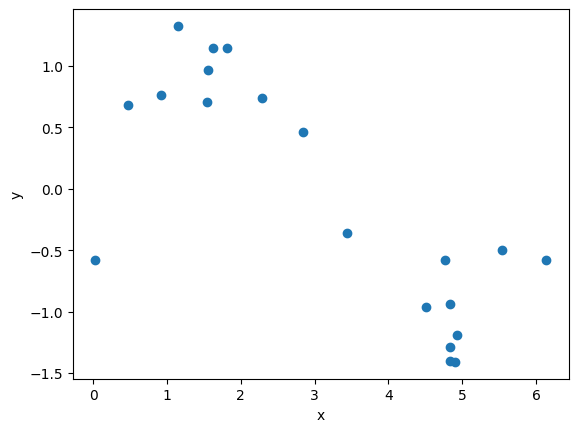

In [6]:
n = 20  # number of data points

# Simulated data:
x_data = 2*np.pi*np.random.rand(n)
noise_amp = 0.3
noise = noise_amp*np.random.randn(n)
y_data = np.sin(x_data) + noise

plt.plot(x_data, y_data, 'o')
plt.xlabel('x')
plt.ylabel('y')

We'll fit this data with a polynomial, as before, except that this time we'll do it from scratch rather than using a built-in Numpy function.

**Exercise**: Using the data above, create a polynomial feature vector for each data point and combine these feature vectors into a design matrix $\Phi_{nj} = \phi_j(x_n) = x_n^j$, where $x_n$ is one of the data points, and $j=0, \ldots, M-1$.

In [7]:
m = 10
phi = np.zeros((n,m))
for j in range(m):
    phi[:,j] = x_data**j
phi

array([[1.00000000e+00, 4.82939976e+00, 2.33231021e+01, 1.12636584e+02,
        5.43967091e+02, 2.62703454e+03, 1.26870000e+04, 6.12705948e+04,
        2.95900196e+05, 1.42902034e+06],
       [1.00000000e+00, 1.62875508e+00, 2.65284311e+00, 4.32083170e+00,
        7.03757659e+00, 1.14624886e+01, 1.86695866e+01, 3.04081840e+01,
        4.95274843e+01, 8.06681417e+01],
       [1.00000000e+00, 2.28853373e+00, 5.23738662e+00, 1.19859359e+01,
        2.74302187e+01, 6.27749806e+01, 1.43662660e+02, 3.28776844e+02,
        7.52416896e+02, 1.72193144e+03],
       [1.00000000e+00, 4.70828007e-01, 2.21679012e-01, 1.04372687e-01,
        4.91415843e-02, 2.31372342e-02, 1.08936578e-02, 5.12903921e-03,
        2.41489531e-03, 1.13700034e-03],
       [1.00000000e+00, 3.43298858e+00, 1.17854106e+01, 4.04591799e+01,
        1.38895903e+02, 4.76828047e+02, 1.63694524e+03, 5.61961431e+03,
        1.92920717e+04, 6.62294619e+04],
       [1.00000000e+00, 2.83759792e+00, 8.05196193e+00, 2.28482304e+01,
   

Our goal is to fit the above data as a function $y(x_n, \vec{w}) = \vec{w} \cdot \vec{\phi}(x_n)$, choosing parameter vector $\mathbf{w}$ to optimize the following loss function:
$$
E(\vec{w}) = \frac{1}{2} \sum_{n=1}^N [t_n - y(x_n, \vec{w})]^2 
+ \frac{\alpha}{2} |\vec{w}|^2,
$$
where $t_n$ is the y coordinate of data point $n$.
As we showed in class, the solution is given by
$$
\vec{w} = [\alpha I + \Phi^\top \Phi ]^{-1} \Phi^\top \vec{t}
$$

**Exercise**: Using the above solution for $\vec{w}$, plot the prediction curve $y(x, \vec{w})$ along with the data. Try doing this with a few different values of $\alpha$ and see how the curves differ.

/var/folders/d9/knlg55l15pjb6fkpbymldjv00000gn/T/ipykernel_54139/407703735.py:3: RuntimeWarning: divide by zero encountered in matmul
  w = np.linalg.inv(alpha * np.eye(m) + (phi.T @ phi)) @ phi.T @ y_data
/var/folders/d9/knlg55l15pjb6fkpbymldjv00000gn/T/ipykernel_54139/407703735.py:3: RuntimeWarning: overflow encountered in matmul
  w = np.linalg.inv(alpha * np.eye(m) + (phi.T @ phi)) @ phi.T @ y_data
/var/folders/d9/knlg55l15pjb6fkpbymldjv00000gn/T/ipykernel_54139/407703735.py:3: RuntimeWarning: invalid value encountered in matmul
  w = np.linalg.inv(alpha * np.eye(m) + (phi.T @ phi)) @ phi.T @ y_data
/var/folders/d9/knlg55l15pjb6fkpbymldjv00000gn/T/ipykernel_54139/407703735.py:9: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  y_pred[i] = np.sum(w[j] * x**j for j in range(m))


Text(0, 0.5, 'y')

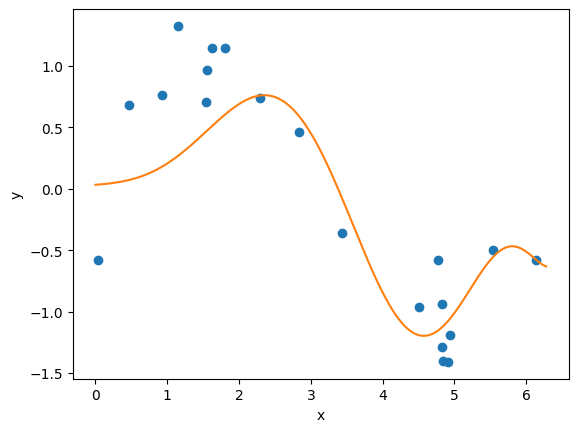

In [ ]:
## Solution ##
alpha = 100 # hyperparameter
w = np.linalg.inv(alpha * np.eye(m) + (phi.T @ phi)) @ phi.T @ y_data

# Plot the results
x_array = np.arange(0, 2*np.pi, 0.01)
y_pred = np.zeros_like(x_array)
for i, x in enumerate(x_array):
    y_pred[i] = np.sum(w[j] * x**j for j in range(m))
plt.plot(x_data, y_data, 'o', label='Data')
plt.plot(x_array,y_pred)
plt.xlabel('x')
plt.ylabel('y')
